In [1]:
%%time
import sys, os
path_dir = os.getcwd()
sys.path.append(path_dir+"/Functions")
from General_functions import *
from Input_func import *
from IO_Plots import *
from PC_Plots import *
from DCN_Plots import *
from New_func import *
from Raster_hist_plots import *
from read_data import *
from CS_Kernels import *
start_scope()
###################################################################
######################### Load Parameters #########################
###################################################################
# Name_BCM = "Learned_BCM"
# time_now_BCM = "09:15"
# Name_No_BCM = "No_BCM"
# time_now_No_BCM = "09:47"
# date = "06-07"
Name_BCM = "Learned_BCM"
time_now_BCM = "21:54"
Name_No_BCM = "No_BCM"
time_now_No_BCM = "15:10"
date = "06-10"
Frozen_data = sio.loadmat('Data/'+date+'/Frozen.mat', squeeze_me=True)
Params, Noise_frozen, Values, Synapses = Read_Input(Frozen_data)
###################################################################
############################ Load Data ############################
###################################################################
Output_Noise_No_BCM, Output_Noise_Extended_No_BCM, Output_PC_No_BCM, Output_DCN_No_BCM, Output_IO_No_BCM, Output_mon_N_PC_No_BCM, Output_Noise_Coupled_No_BCM, Output_Noise_Extended_Coupled_No_BCM, Output_PC_Coupled_No_BCM, Output_DCN_Coupled_No_BCM, Output_IO_Coupled_No_BCM, Output_mon_N_PC_Coupled = load_data(Name_No_BCM, time_now_No_BCM, date)
Output_Noise_BCM, Output_Noise_Extended_BCM, Output_PC_BCM, Output_DCN_BCM, Output_IO_BCM, Output_mon_N_PC_BCM, Output_Noise_Coupled_BCM, Output_Noise_Extended_Coupled_BCM, Output_PC_Coupled_BCM, Output_DCN_Coupled_BCM, Output_IO_Coupled_BCM, Output_mon_N_PC_Coupled = load_data(Name_BCM, time_now_BCM, date)
###################################################################
########################### Load Cells ############################
###################################################################
Noise_BCM, Noise_Extended_BCM, PC_BCM, DCN_BCM, IO_BCM, mon_N_PC_BCM = Output_func(Name_BCM,"",Output_Noise_BCM, Output_Noise_Extended_BCM, Output_PC_BCM, Output_DCN_BCM, Output_IO_BCM, Output_mon_N_PC_BCM, Output_Noise_Coupled_BCM, Output_Noise_Extended_Coupled_BCM, Output_PC_Coupled_BCM, Output_DCN_Coupled_BCM, Output_IO_Coupled_BCM, Output_mon_N_PC_Coupled)
Noise_Coupled_BCM, Noise_Extended_Coupled_BCM, PC_Coupled_BCM, DCN_Coupled_BCM, IO_Coupled_BCM, mon_N_PC_Coupled_BCM = Output_func(Name_BCM,"Coupled",Output_Noise_BCM, Output_Noise_Extended_BCM, Output_PC_BCM, Output_DCN_BCM, Output_IO_BCM, Output_mon_N_PC_BCM, Output_Noise_Coupled_BCM, Output_Noise_Extended_Coupled_BCM, Output_PC_Coupled_BCM, Output_DCN_Coupled_BCM, Output_IO_Coupled_BCM, Output_mon_N_PC_Coupled)
time_x_BCM = Noise_BCM.t

Noise_No_BCM, Noise_Extended_No_BCM, PC_No_BCM, DCN_No_BCM, IO_No_BCM, mon_N_PC_No_BCM = Output_func(Name_No_BCM,"",Output_Noise_No_BCM, Output_Noise_Extended_No_BCM, Output_PC_No_BCM, Output_DCN_No_BCM, Output_IO_No_BCM, Output_mon_N_PC_No_BCM, Output_Noise_Coupled_No_BCM, Output_Noise_Extended_Coupled_No_BCM, Output_PC_Coupled_No_BCM, Output_DCN_Coupled_No_BCM, Output_IO_Coupled_No_BCM, Output_mon_N_PC_Coupled)
Noise_No_Coupled_No_BCM, Noise_Extended_Coupled_No_BCM, PC_Coupled_No_BCM, DCN_Coupled_No_BCM, IO_Coupled_No_BCM, mon_N_PC_Coupled_No_BCM = Output_func(Name_No_BCM,"Coupled",Output_Noise_No_BCM, Output_Noise_Extended_No_BCM, Output_PC_No_BCM, Output_DCN_No_BCM, Output_IO_No_BCM, Output_mon_N_PC_No_BCM, Output_Noise_Coupled_No_BCM, Output_Noise_Extended_Coupled_No_BCM, Output_PC_Coupled_No_BCM, Output_DCN_Coupled_No_BCM, Output_IO_Coupled_No_BCM, Output_mon_N_PC_Coupled)
time_x_No_BCM = Noise_No_BCM.t

step1 = 550
step = int(step1/(Params.dt_rec/msecond))
xx = range(-step,step)
xx1 = [item * (Params.dt_rec/msecond) for item in xx]
half = int(time_x_BCM[len(time_x_BCM)//2]/1000)

### Uncoupled
PC_new_No_BCM = New_PC(Params,PC_No_BCM)
PC_new_Coupled_No_BCM = New_PC(Params,PC_Coupled_No_BCM)
IO_CS_No_BCM, IO_Size_No_BCM, cc_No_BCM, avrg_CS_No_BCM, avrg_CS_all_No_BCM = CS_plots(step,"",Params,Synapses,IO_No_BCM)
IO_CS_Coupled_No_BCM, IO_Size_Coupled_No_BCM, cc_Coupled_No_BCM, avrg_CS_Coupled_No_BCM, avrg_CS_all_Coupled_No_BCM = CS_plots(step,"",Params,Synapses,IO_Coupled_No_BCM)
PC_CS_No_BCM, cc_PC_No_BCM, avrg_PC_No_BCM, avrg_PC_all_No_BCM = CS_PC(step,"",Params,Synapses,PC_new_No_BCM,IO_No_BCM)
PC_CS_Coupled_No_BCM, cc_PC_Coupled_No_BCM, avrg_PC_Coupled_No_BCM, avrg_PC_all_Coupled_No_BCM = CS_PC(step,"",Params,Synapses,PC_new_Coupled_No_BCM,IO_Coupled_No_BCM)
### Coupled
PC_new_BCM = New_PC_learned(Params,PC_BCM)
PC_new_Coupled_BCM = New_PC_learned(Params,PC_Coupled_BCM)
IO_CS_BCM, IO_Size_BCM, cc_BCM, avrg_CS_BCM, avrg_CS_all_BCM = CS_plots(step,"",Params,Synapses,IO_BCM)
IO_CS_Coupled_BCM, IO_Size_Coupled_BCM, cc_Coupled_BCM, avrg_CS_Coupled_BCM, avrg_CS_all_Coupled_BCM = CS_plots(step,"",Params,Synapses,IO_Coupled_BCM)
PC_CS_BCM, cc_PC_BCM, avrg_PC_BCM, avrg_PC_all_BCM = CS_PC(step,"",Params,Synapses,PC_new_BCM,IO_BCM)
PC_CS_Coupled_BCM, cc_PC_Coupled_BCM, avrg_PC_Coupled_BCM, avrg_PC_all_Coupled_BCM = CS_PC(step,"",Params,Synapses,PC_new_Coupled_BCM,IO_Coupled_BCM)


PC_CS_rate_No_BCM, cc_rate_No_BCM, avrg_PC_rate_No_BCM, avrg_PC_all_rate_No_BCM = PC_CS_rate(step,"",Params,Synapses,PC_No_BCM,IO_No_BCM)
PC_CS_rate_Coupled_No_BCM, cc_rate_Coupled_No_BCM, avrg_PC_rate_Coupled_No_BCM, avrg_PC_all_rate_Coupled_No_BCM = PC_CS_rate(step,"",Params,Synapses,PC_Coupled_No_BCM,IO_Coupled_No_BCM)

PC_CS_rate_BCM, cc_rate_BCM, avrg_PC_rate_BCM, avrg_PC_all_rate_BCM = PC_CS_rate(step,"Learned",Params,Synapses,PC_BCM,IO_BCM)
PC_CS_rate_Coupled_BCM, cc_rate_Coupled_BCM, avrg_PC_rate_Coupled_BCM, avrg_PC_all_rate_Coupled_BCM = PC_CS_rate(step,"Learned",Params,Synapses,PC_Coupled_BCM,IO_Coupled_BCM)

CPU times: user 9min 44s, sys: 20.4 s, total: 10min 5s
Wall time: 10min 10s


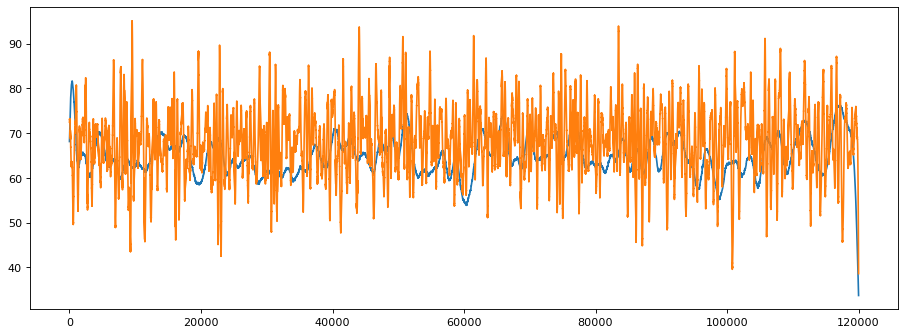

In [2]:
figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
plot(PC_No_BCM.rate_time,PC_No_BCM.rate)
plot(PC_No_BCM.rate_time,PC_BCM.rate[len(PC_BCM.rate)//2:])

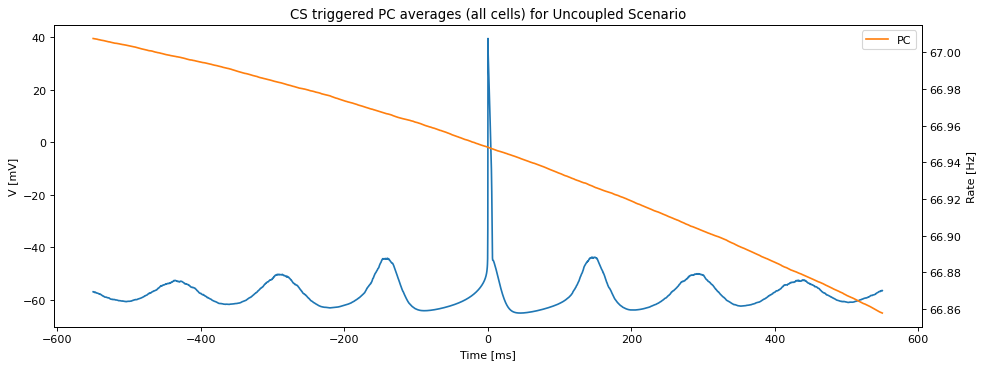

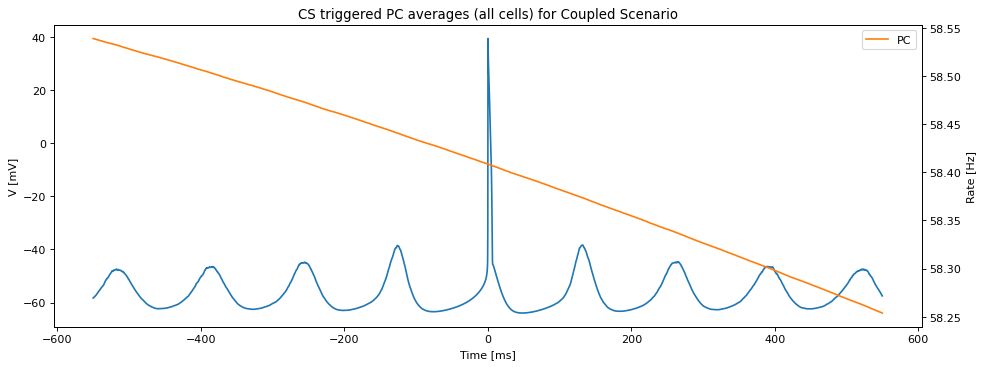

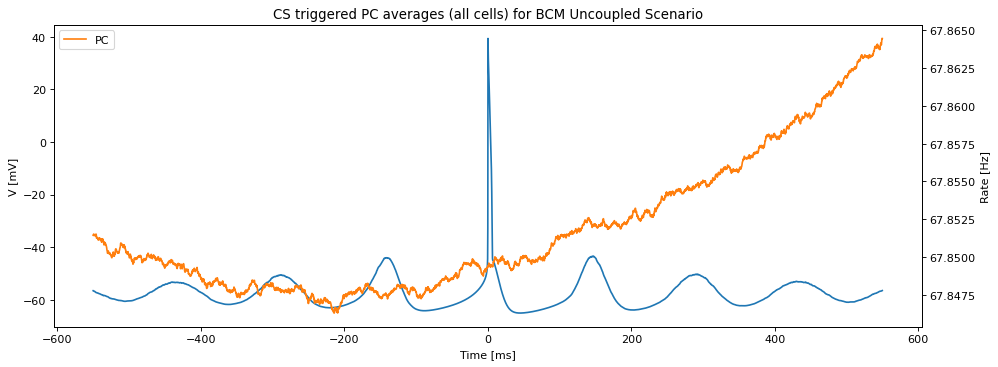

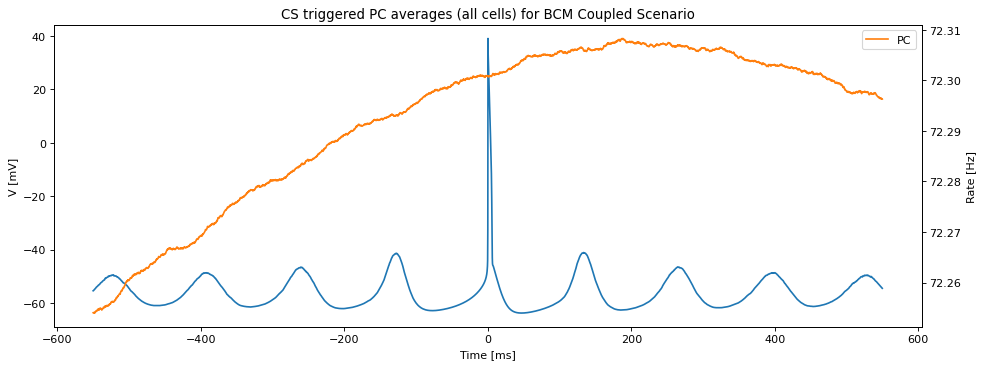

In [7]:
fig, ax1 = plt.subplots(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
ax2 = ax1.twinx()
ax1.plot(xx1,avrg_CS_all_No_BCM/mV,label="IO")
ax2.plot(xx1,avrg_PC_all_rate_No_BCM/Hz,label="PC",color="C1")
title('CS triggered PC averages (all cells) for Uncoupled Scenario')
ax1.set_ylabel('V [mV]')
ax2.set_ylabel('Rate [Hz]')
ax1.set_xlabel('Time [ms]')
legend()
show()

fig, ax1 = plt.subplots(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
ax2 = ax1.twinx()
ax1.plot(xx1,avrg_CS_all_Coupled_No_BCM/mV,label="IO")
ax2.plot(xx1,avrg_PC_all_rate_Coupled_No_BCM/Hz,label="PC",color="C1")
title('CS triggered PC averages (all cells) for Coupled Scenario')
ax1.set_ylabel('V [mV]')
ax2.set_ylabel('Rate [Hz]')
ax1.set_xlabel('Time [ms]')
legend()
show()

fig, ax1 = plt.subplots(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
ax2 = ax1.twinx()
ax1.plot(xx1,avrg_CS_all_BCM/mV,label="IO")
ax2.plot(xx1,avrg_PC_all_rate_BCM/Hz,label="PC",color="C1")
title('CS triggered PC averages (all cells) for BCM Uncoupled Scenario')
ax1.set_ylabel('V [mV]')
ax2.set_ylabel('Rate [Hz]')
ax1.set_xlabel('Time [ms]')
legend()
show()

fig, ax1 = plt.subplots(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
ax2 = ax1.twinx()
ax1.plot(xx1,avrg_CS_all_Coupled_BCM/mV,label="IO")
ax2.plot(xx1,avrg_PC_all_rate_Coupled_BCM/Hz,label="PC",color="C1")
title('CS triggered PC averages (all cells) for BCM Coupled Scenario')
ax1.set_ylabel('V [mV]')
ax2.set_ylabel('Rate [Hz]')
ax1.set_xlabel('Time [ms]')
legend()
show()

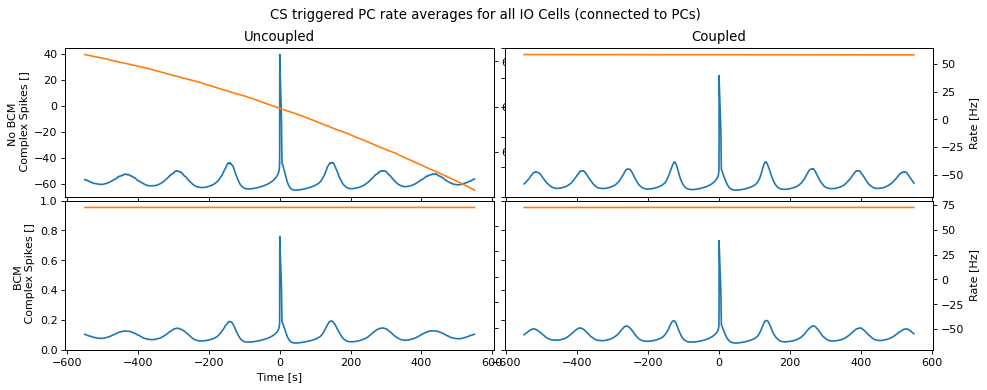

In [4]:
fig = plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
fig.suptitle('CS triggered PC rate averages for all IO Cells (connected to PCs)')
gs1 = gridspec.GridSpec(2, 2)
gs1.update(wspace=0.025, hspace=0.025) # set the spacing between axes. 

ax1 = plt.subplot(gs1[0])
ylabel('No BCM \n Complex Spikes []')
plt.title('Uncoupled')
ax1.set_xticklabels([])
ax2 = ax1.twinx()
ax1.plot(xx1,avrg_CS_all_No_BCM/mV,label="IO")
ax2.plot(xx1,avrg_PC_all_rate_No_BCM/Hz,label="PC Rate",color="C1")

ax3 = plt.subplot(gs1[1])
plt.title('Coupled')
ax3.set_yticklabels([])
ax3.set_xticklabels([])
ax4 = ax3.twinx()
ax4.set_ylabel('Rate [Hz]')
ax3 = plt.plot(xx1,avrg_CS_all_Coupled_No_BCM/mV,label="IO")
ax4 = plt.plot(xx1,avrg_PC_all_rate_Coupled_No_BCM/Hz,label="PC Rate",color="C1")

ax5 = plt.subplot(gs1[2])
ylabel('BCM \n Complex Spikes []')
xlabel('Time [s]')
ax6 = ax5.twinx()
ax6.set_yticklabels([])
ax5 = plt.plot(xx1,avrg_CS_all_BCM/mV,label="IO")
ax6 = plt.plot(xx1,avrg_PC_all_rate_BCM/Hz,label="PC Rate",color="C1")

ax7 = plt.subplot(gs1[3])
ax7.set_yticklabels([])
ax8 = ax7.twinx()
ax8.set_ylabel('Rate [Hz]')
ax7 = plt.plot(xx1,avrg_CS_all_Coupled_BCM/mV,label="IO")
ax8 = plt.plot(xx1,avrg_PC_all_rate_Coupled_BCM/Hz,label="PC Rate",color="C1")
xlabel('Time [s]')
plt.show() 

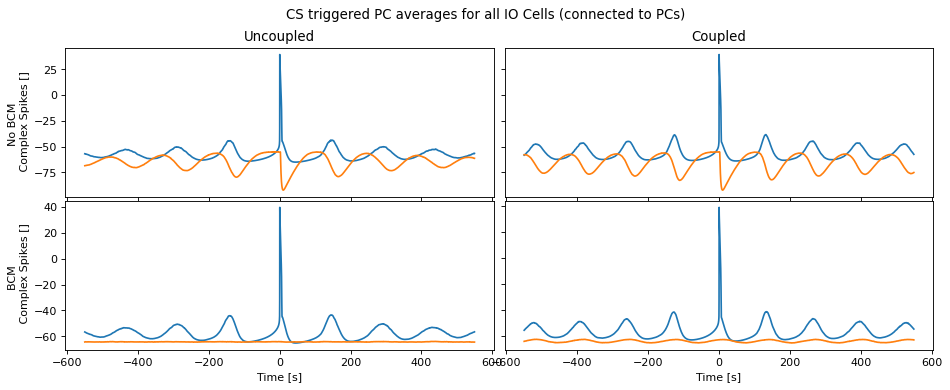

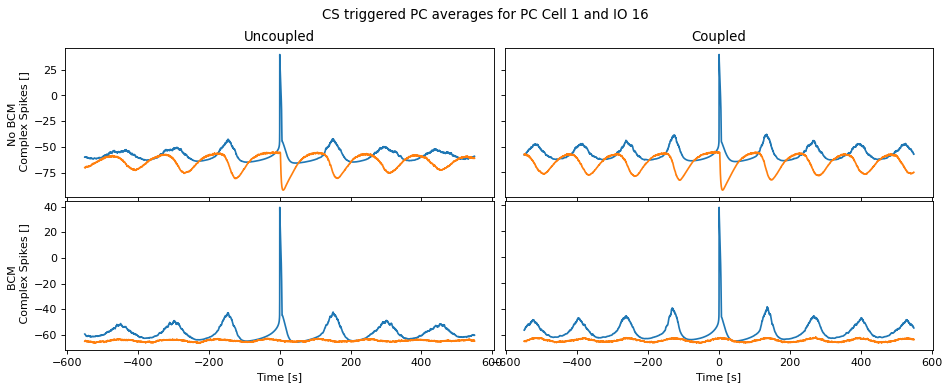

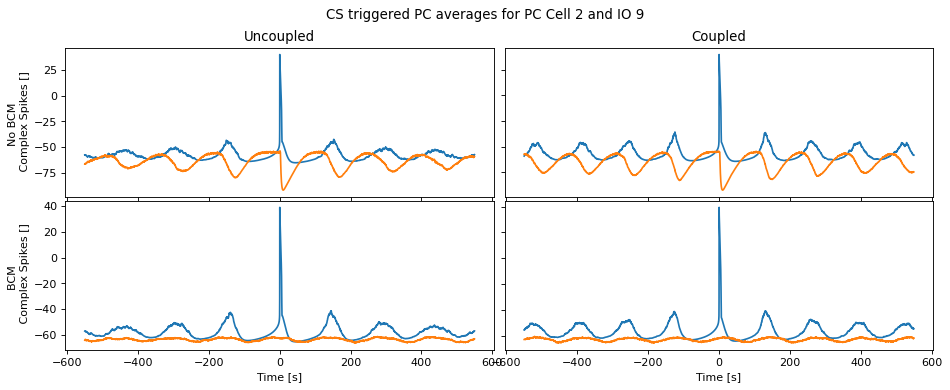

IndexError: list index out of range

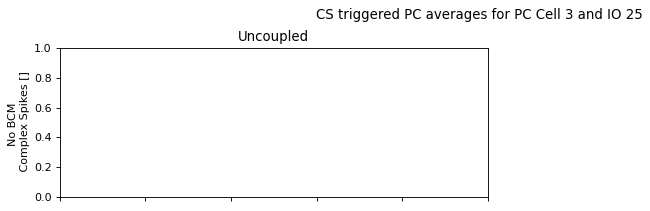

In [5]:
CS_SS_avr_all_comp(xx1,avrg_CS_all_No_BCM,avrg_PC_all_No_BCM,avrg_CS_all_Coupled_No_BCM,avrg_PC_all_Coupled_No_BCM,avrg_CS_all_BCM,avrg_PC_all_BCM,avrg_CS_all_Coupled_BCM,avrg_PC_all_Coupled_BCM)
CS_SS_avr_comp(Params,Synapses,xx1,avrg_CS_No_BCM,avrg_PC_No_BCM,avrg_CS_Coupled_No_BCM,avrg_PC_Coupled_No_BCM,avrg_CS_BCM,avrg_PC_BCM,avrg_CS_Coupled_BCM,avrg_PC_Coupled_BCM)

In [14]:
kk = 0
learned = "Learned"
IO = IO_BCM
IO_CS = [[]]*size(Synapses.IO_PC_Synapse_Sources)
for ii in Synapses.IO_PC_Synapse_Sources:
    if learned == "Learned":
        IO_spikes = IO.Spikemon_Cells[ii][len(IO.Spikemon_Cells[ii])//2:]
    else: 
        IO_spikes = IO.Spikemon_Cells[ii][:len(IO.Spikemon_Cells[ii])//2]
    IO_CS[kk] = [[]]*size(IO_spikes)
    for jj in range(0,size(IO_spikes)):
        spike = IO_spikes[jj]/(Params.dt_rec/second)
        IO_CS[kk][jj] = (IO.Vs[ii][int(spike-step):int(spike+step)]/mV)
    kk += 1

IO_Size = [[]]*len(IO_CS)
for ii in range(0,len(IO_CS)):
    IO_Size[ii] = [[]]*len(IO_CS[ii])
    for jj in range(0,len(IO_CS[ii])):
        IO_Size[ii][jj] = len(IO_CS[ii][jj]) 

kk = 0
aa = [[]]*size(Synapses.IO_PC_Synapse_Sources)
bb = [[]]*size(Synapses.IO_PC_Synapse_Sources)
cc = [[]]*size(Synapses.IO_PC_Synapse_Sources)
for ii in Synapses.IO_PC_Synapse_Sources:
    if learned == "Learned":
        IO_spikes = IO.Spikemon_Cells[ii][len(IO.Spikemon_Cells[ii])//2:]
    else: 
        IO_spikes = IO.Spikemon_Cells[ii][:len(IO.Spikemon_Cells[ii])//2]
    aa[kk] = [[]]*size(IO_spikes)
    bb[kk] = [[]]*size(IO_spikes)
    for jj in range(0,size(IO_spikes)):
        spike = IO_spikes[jj]/(Params.dt_rec/second)
        aa[kk][jj] = IO.Vs[ii][int(spike-step):int(spike+step)]
        if size(aa[kk][jj]) != most_frequent(IO_Size[kk]):
            continue
        bb[kk][jj] = IO.Vs[ii][int(spike-step):int(spike+step)]
    cc[kk] = [x for x in bb[kk] if x != []]    
    kk+=1

WARNING    <ipython-input-14-ea59c51ba091>:39: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  cc[kk] = [x for x in bb[kk] if x != []]
 [py.warnings]
  cc[kk] = [x for x in bb[kk] if x != []]



In [18]:
Params.N_Cells_IO

40

In [ ]:
avrg_CS = [[]]*len(cc)
for ii in range(0,len(cc)):
    avrg_CS[ii] = np.mean(cc[ii], axis=0)

avrg_CS_all = np.mean(avrg_CS, axis=0)

15


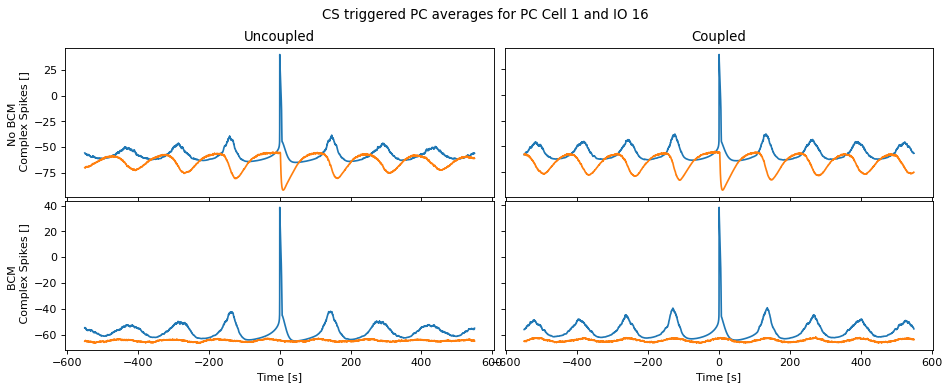

8


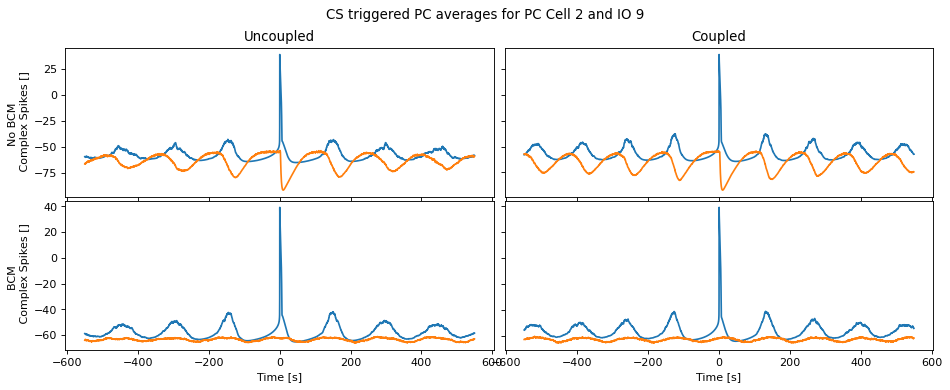

24


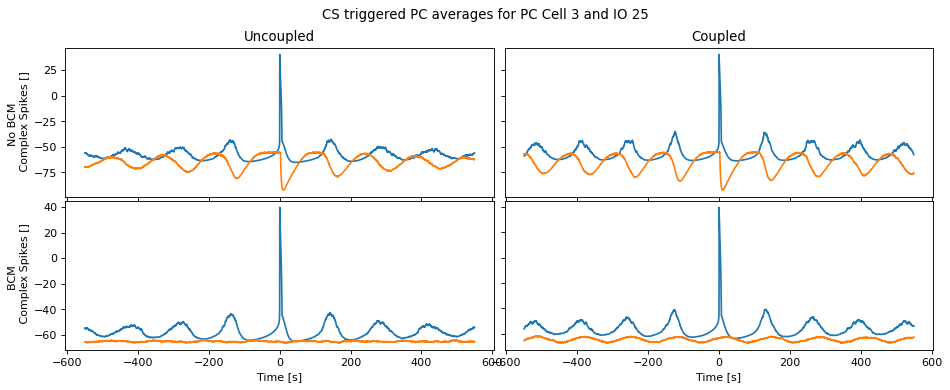

14


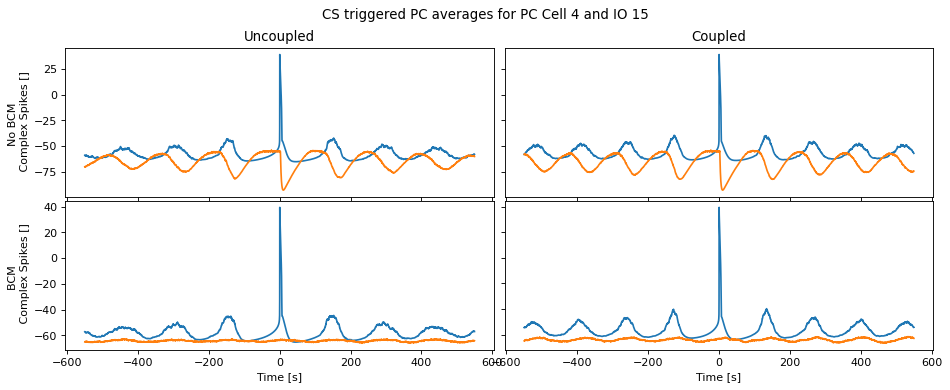

27


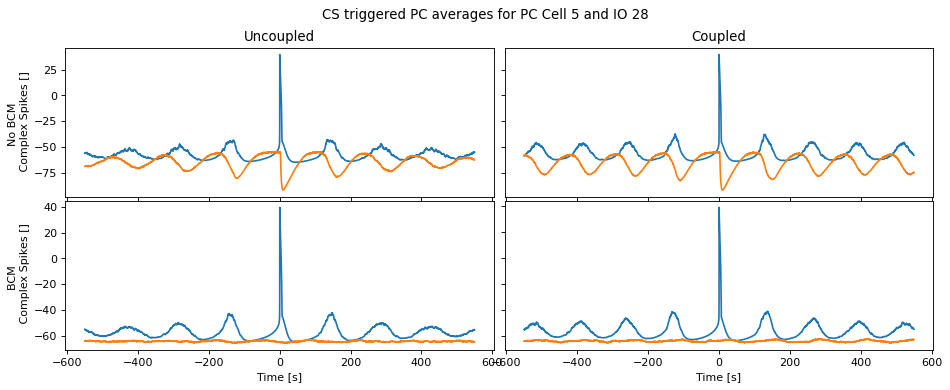

1


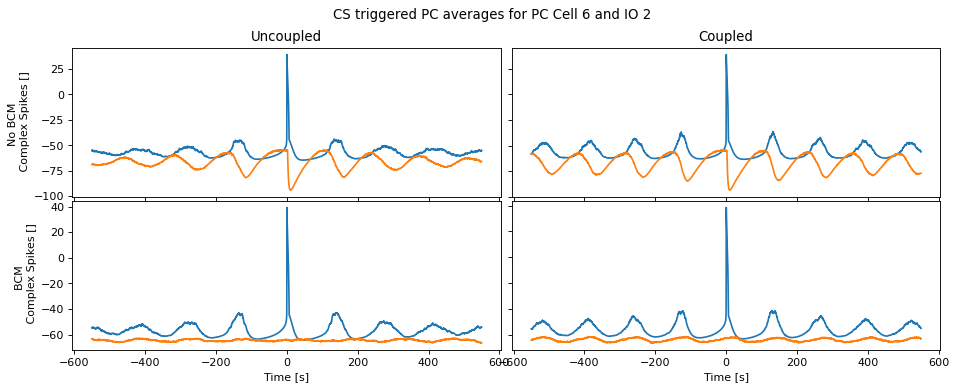

16


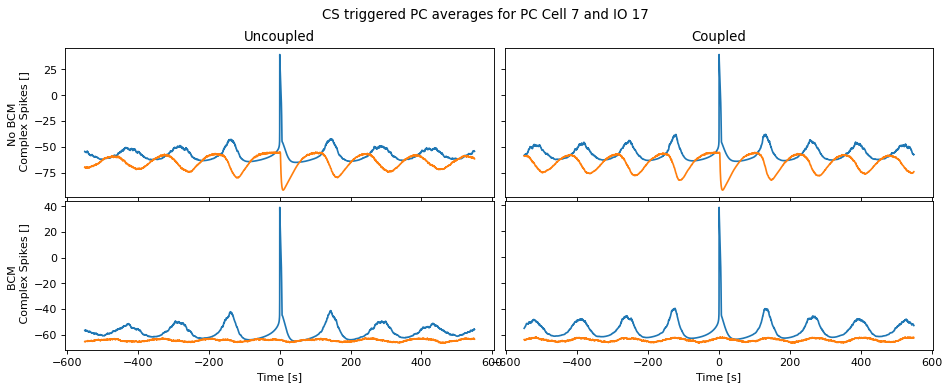

0


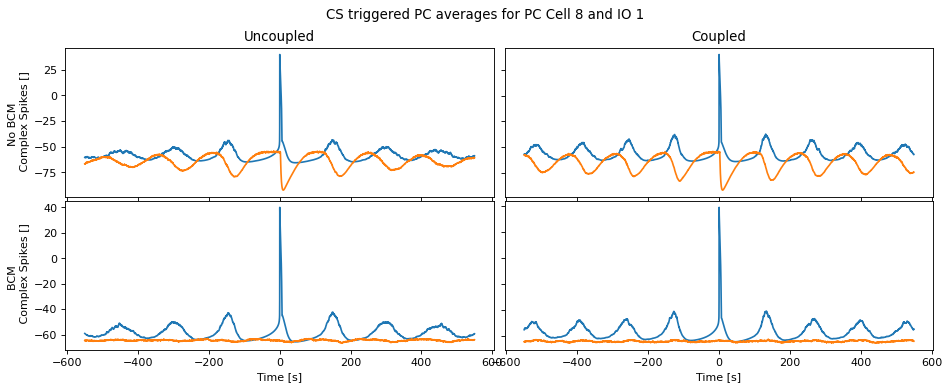

30


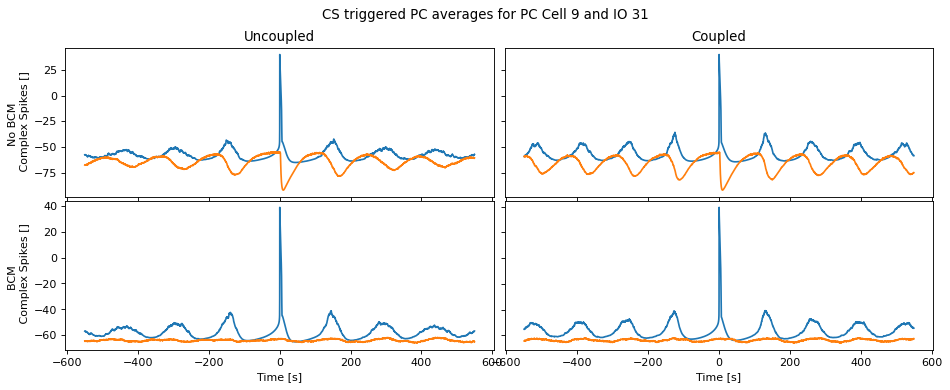

35


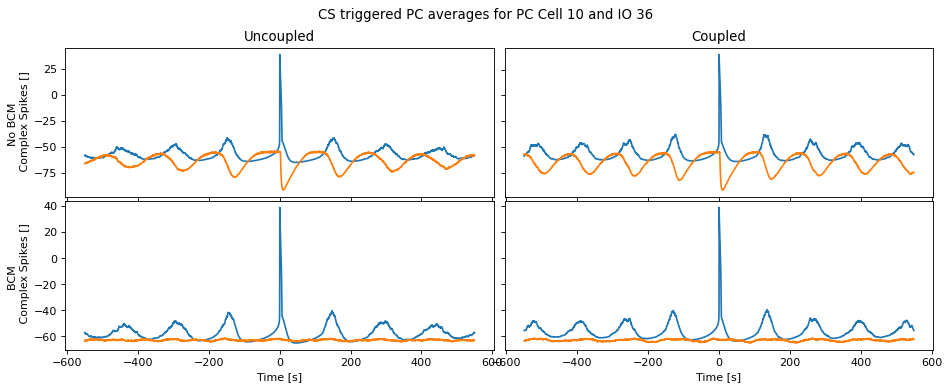

3


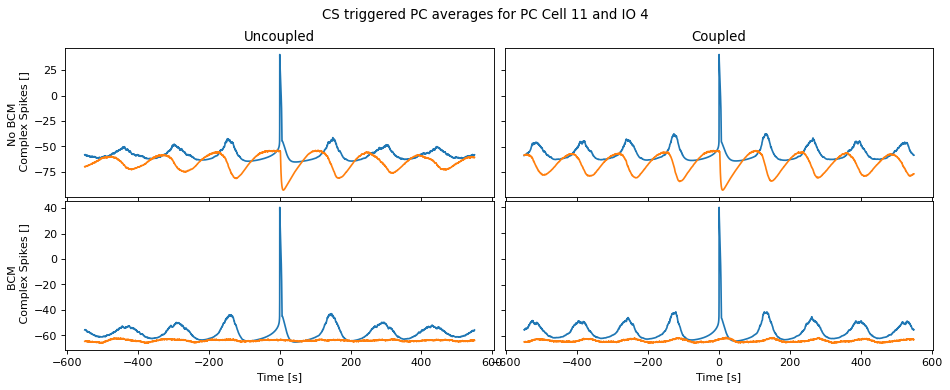

7


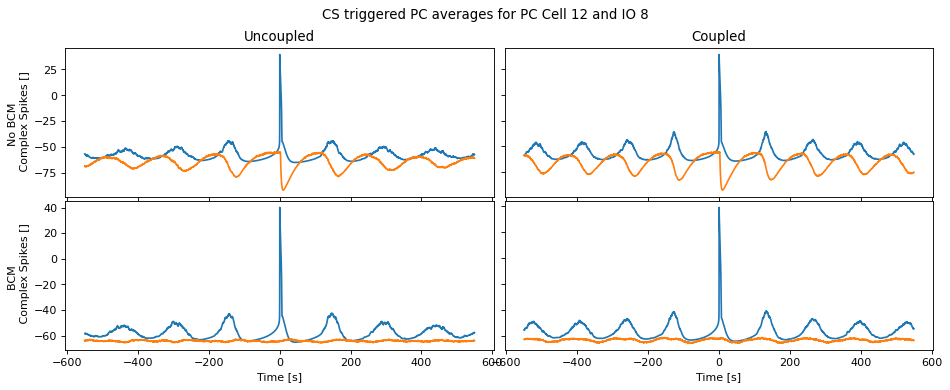

33


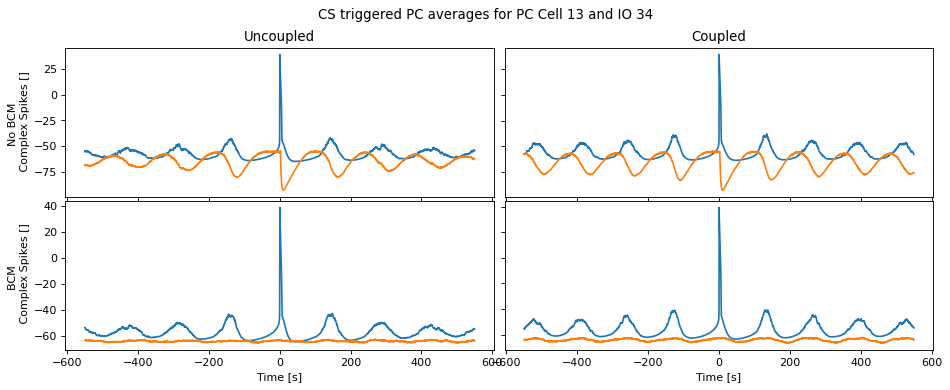

10


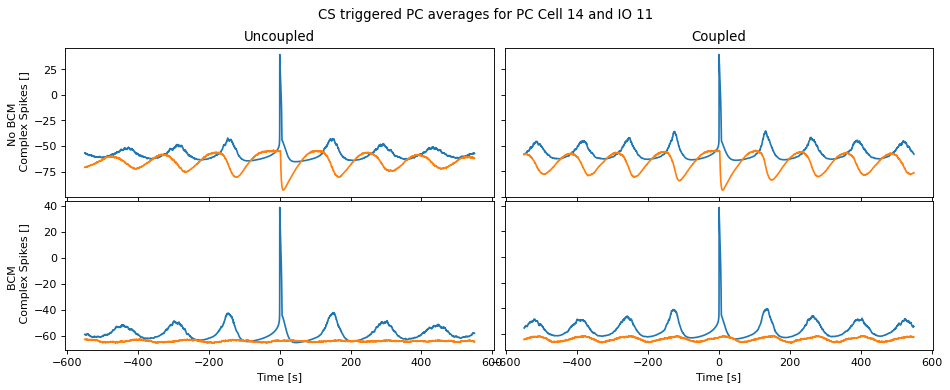

19


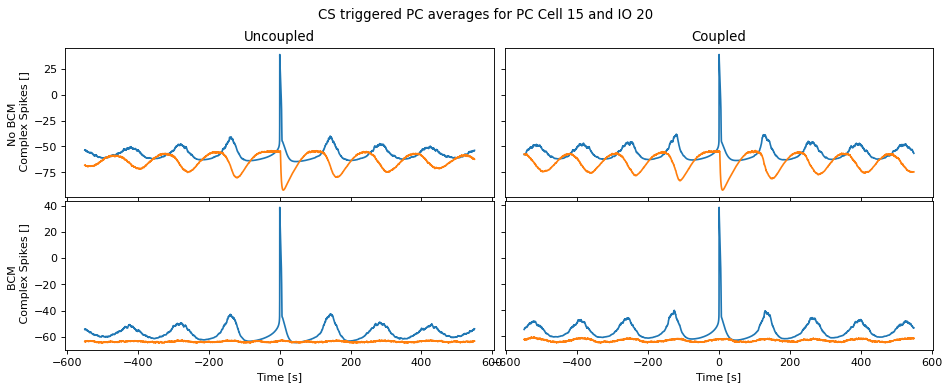

6


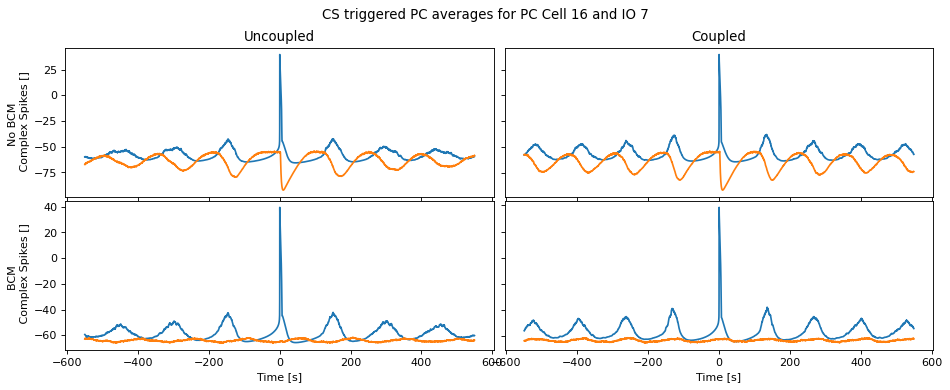

29


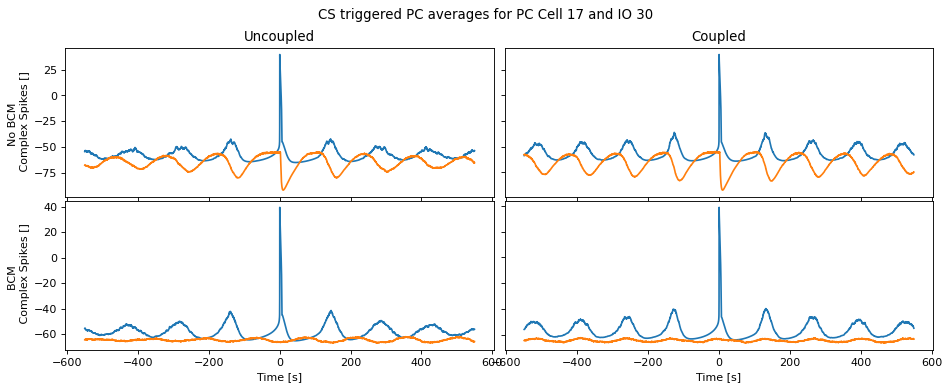

28


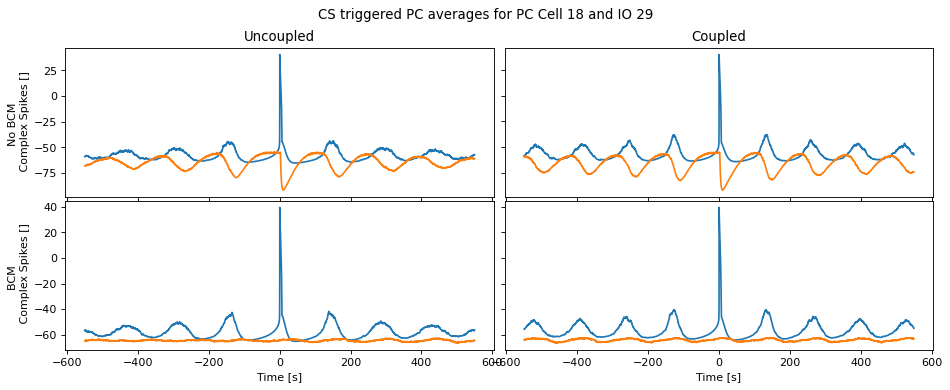

13


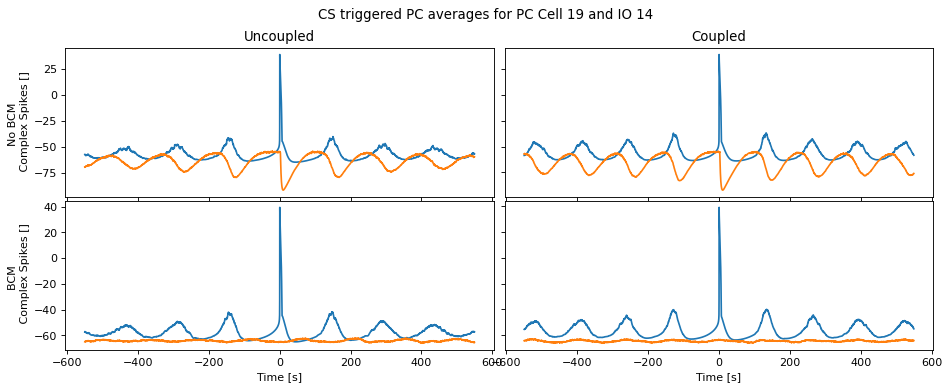

17


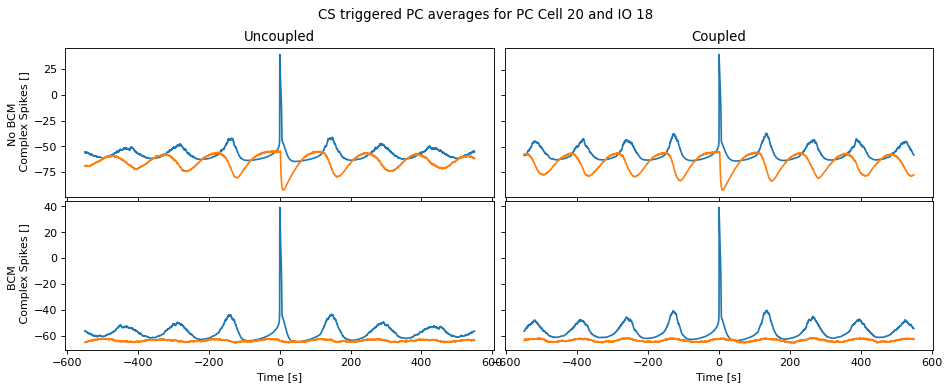

In [19]:
for ii in range(0,Params.N_Cells_PC):
    jj = Synapses.IO_PC_Synapse_Sources[ii]
    print(jj)
    fig = plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
    fig.suptitle('CS triggered PC averages for PC Cell '+str(ii+1)+' and IO '+str(jj+1))
    gs1 = gridspec.GridSpec(2, 2)
    gs1.update(wspace=0.025, hspace=0.025) # set the spacing between axes. 

    ax1 = plt.subplot(gs1[0])
    ylabel('No BCM \n Complex Spikes []')
    plt.title('Uncoupled')
    ax1.set_xticklabels([])
    ax1 = plt.plot(xx1,avrg_CS_No_BCM[ii]/mV,label="IO")
    ax1 = plt.plot(xx1,avrg_PC_No_BCM[ii]/mV,label="PC")

    ax2 = plt.subplot(gs1[1])
    plt.title('Coupled')
    ax2.set_yticklabels([])
    ax2.set_xticklabels([])
    ax2 = plt.plot(xx1,avrg_CS_Coupled_No_BCM[ii]/mV,label="IO")
    ax2 = plt.plot(xx1,avrg_PC_Coupled_No_BCM[ii]/mV,label="PC")

    ax3 = plt.subplot(gs1[2])
    ylabel('BCM \n Complex Spikes []')
    xlabel('Time [s]')
    ax3 = plt.plot(xx1,avrg_CS_BCM[ii]/mV,label="IO")
    ax3 = plt.plot(xx1,avrg_PC_BCM[ii]/mV,label="PC")

    ax4 = plt.subplot(gs1[3])
    ax4.set_yticklabels([])
    ax4 = plt.plot(xx1,avrg_CS_Coupled_BCM[ii]/mV,label="IO")
    ax4 = plt.plot(xx1,avrg_PC_Coupled_BCM[ii]/mV,label="PC")
    xlabel('Time [s]')
    plt.show()

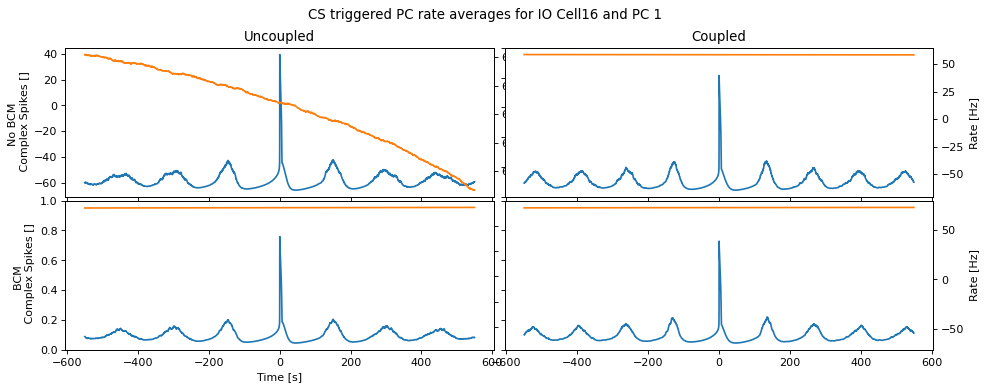

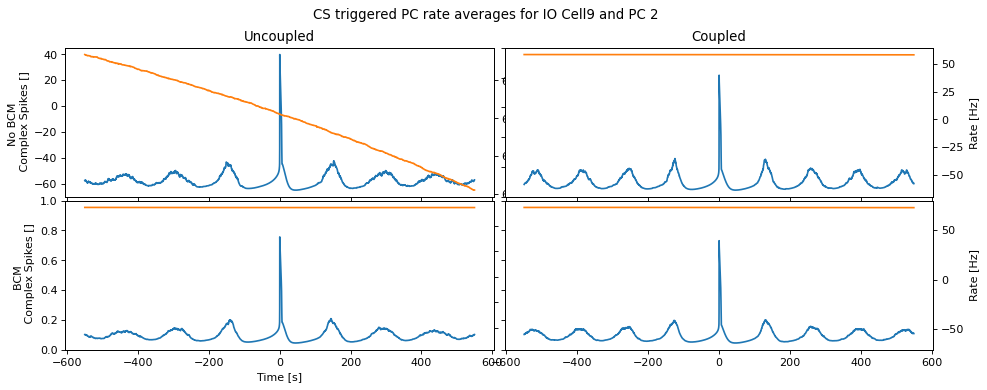

IndexError: list index out of range

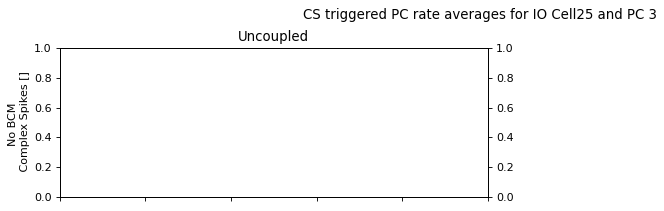

In [6]:
for ii in range(0,Params.N_Cells_PC):
    jj = Synapses.IO_PC_Synapse_Sources[ii]
    fig = plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
    fig.suptitle('CS triggered PC rate averages for IO Cell'+ str(jj+1)+' and PC '+str(ii+1))
    gs1 = gridspec.GridSpec(2, 2)
    gs1.update(wspace=0.025, hspace=0.025) # set the spacing between axes. 

    ax1 = plt.subplot(gs1[0])
    ylabel('No BCM \n Complex Spikes []')
    plt.title('Uncoupled')
    ax1.set_xticklabels([])
    ax2 = ax1.twinx()
    ax1.plot(xx1,avrg_CS_No_BCM[jj]/mV,label="IO")
    ax2.plot(xx1,avrg_PC_rate_No_BCM[ii]/Hz,label="PC Rate",color="C1")

    ax3 = plt.subplot(gs1[1])
    plt.title('Coupled')
    ax3.set_yticklabels([])
    ax3.set_xticklabels([])
    ax4 = ax3.twinx()
    ax4.set_ylabel('Rate [Hz]')
    ax3 = plt.plot(xx1,avrg_CS_Coupled_No_BCM[jj]/mV,label="IO")
    ax4 = plt.plot(xx1,avrg_PC_rate_Coupled_No_BCM[ii]/Hz,label="PC Rate",color="C1")

    ax5 = plt.subplot(gs1[2])
    ylabel('BCM \n Complex Spikes []')
    xlabel('Time [s]')
    ax6 = ax5.twinx()
    ax6.set_yticklabels([])
    ax5 = plt.plot(xx1,avrg_CS_BCM[jj]/mV,label="IO")
    ax6 = plt.plot(xx1,avrg_PC_rate_BCM[ii]/Hz,label="PC Rate",color="C1")

    ax7 = plt.subplot(gs1[3])
    ax7.set_yticklabels([])
    ax8 = ax7.twinx()
    ax8.set_ylabel('Rate [Hz]')
    ax7 = plt.plot(xx1,avrg_CS_Coupled_BCM[jj]/mV,label="IO")
    ax8 = plt.plot(xx1,avrg_PC_rate_Coupled_BCM[ii]/Hz,label="PC Rate",color="C1")
    xlabel('Time [s]')
    plt.show() 

In [ ]:
# CS_PC_avr_all('Uncoupled',xx1,avrg_CS_all_No_BCM,avrg_PC_all_No_BCM)
# CS_PC_avr_all('Coupled',xx1,avrg_CS_all_Coupled_No_BCM,avrg_PC_all_Coupled_No_BCM)
# CS_PC_avr_all('BCM Uncoupled',xx1,avrg_CS_all_BCM,avrg_PC_all_BCM)
# CS_PC_avr_all('BCM Coupled',xx1,avrg_CS_all_Coupled_BCM,avrg_PC_all_Coupled_BCM)

In [ ]:
# CS_PC_avr("Uncoupled",Params,xx1,Synapses,avrg_CS_No_BCM,avrg_PC_No_BCM)
# CS_PC_avr("Coupled",Params,xx1,Synapses,avrg_CS_Coupled_No_BCM,avrg_PC_Coupled_No_BCM)
# CS_PC_avr("BCM Uncoupled",xx1,Params,Synapses,avrg_CS_BCM,avrg_PC_BCM)
# CS_PC_avr("BCM Coupled",xx1,Params,Synapses,avrg_CS_Coupled_BCM,avrg_PC_Coupled_BCM)